# Expected Fare / Revenue Model

**Emma and lucy** 

This notebook predicts **expected fare** (`fare_amount`) and **revenue** (`total_amount`) at the **individual trip level** using NYC taxi data.

## Workflow
1. Load and prepare the data
2. Carry out EDA
3. Engineer features
4. Build a time-based train/test split
5. Create train-only aggregated features
6. Train and evaluate three models
7. Tune the final model
8. Export predictions

##  Importing the libraries

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

##  Load the data

This version loads only the columns needed for modelling so it runs faster and uses less of my ram.

In [4]:
BASE_DIR = Path.cwd().parents[1]   # notebook is in models/expected_revenue
DATA_DIR = BASE_DIR / "data/data"

use_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "total_amount",
]

def load_data(month_start=1, month_end=12):
    frames = []
    for month in range(month_start, month_end + 1):
        file_path = DATA_DIR / f"nyc_taxi_2024-{month:02d}.csv"
        print(f"Loading {file_path.name}...")
        temp = pd.read_csv(
            file_path,
            usecols=use_cols,
            parse_dates=["tpep_pickup_datetime", "tpep_dropoff_datetime"]
        )
        temp["month"] = month
        frames.append(temp)
    return pd.concat(frames, ignore_index=True)

df = load_data(1, 12)
print("Loaded shape:", df.shape)
df.head()

Loading nyc_taxi_2024-01.csv...
Loading nyc_taxi_2024-02.csv...
Loading nyc_taxi_2024-03.csv...
Loading nyc_taxi_2024-04.csv...
Loading nyc_taxi_2024-05.csv...
Loading nyc_taxi_2024-06.csv...
Loading nyc_taxi_2024-07.csv...
Loading nyc_taxi_2024-08.csv...
Loading nyc_taxi_2024-09.csv...
Loading nyc_taxi_2024-10.csv...
Loading nyc_taxi_2024-11.csv...
Loading nyc_taxi_2024-12.csv...
Loaded shape: (41169720, 9)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,month
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,17.7,22.70,1
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,10.0,18.75,1
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,23.3,31.30,1
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,10.0,17.00,1
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,7.9,16.10,1


##  Basic feature engineering

defining the trip duration, pickup hour, day of the week and whether it is morning or not.

In [5]:
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)
# creating time of day feature same as bhaskar's csv 
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "morning rush"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    else:
        return "night"

df["time_of_day"] = df["pickup_hour"].apply(get_time_of_day)
time_map = {"morning": 0, "afternoon": 1, "evening": 2, "night": 3}
df["time_of_day_code"] = df["time_of_day"].map(time_map)

##  Clean the data

In [6]:
df = df[
    (df["trip_distance"] > 0) &
    (df["trip_duration_minutes"] > 0) &
    (df["fare_amount"] > 0) &
    (df["total_amount"] > 0) &
    (df["trip_distance"] < 100) &
    (df["trip_duration_minutes"] < 300) &
    (df["fare_amount"] < 500) &
    (df["total_amount"] < 500)
].copy()

df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

print("Cleaned shape:", df.shape)

Cleaned shape: (39680361, 16)


##  Quick data overview

In [7]:
print(df.shape)
df.info()

(39680361, 16)
<class 'pandas.DataFrame'>
Index: 39680361 entries, 0 to 41169719
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int64         
 5   DOLocationID           int64         
 6   fare_amount            float64       
 7   total_amount           float64       
 8   month                  int64         
 9   trip_duration_minutes  float64       
 10  pickup_hour            int32         
 11  pickup_dayofweek       int32         
 12  pickup_month           int32         
 13  is_weekend             int64         
 14  time_of_day            str           
 15  time_of_day_code       float64       
dtypes: datetime64[us](2), float64(6), int32(3), int64(4), str(1)
memory usage: 4.6 GB


In [8]:
df[[
    "trip_distance",
    "trip_duration_minutes",
    "fare_amount",
    "total_amount",
    "passenger_count"
]].describe()

,trip_distance,trip_duration_minutes,fare_amount,total_amount,passenger_count
count,3.968036e+07,3.968036e+07,3.968036e+07,3.968036e+07,3.968036e+07
mean,3.422099e+00,1.692555e+01,1.979692e+01,2.862872e+01,1.301632e+00
std,4.428376e+00,1.383708e+01,1.764781e+01,2.229868e+01,7.819519e-01
min,1.000000e-02,1.666667e-02,1.000000e-02,1.000000e-02,0.000000e+00
25%,1.060000e+00,7.966667e+00,9.300000e+00,1.600000e+01,1.000000e+00
50%,1.800000e+00,1.308333e+01,1.420000e+01,2.120000e+01,1.000000e+00
75%,3.400000e+00,2.118333e+01,2.260000e+01,3.070000e+01,1.000000e+00
max,9.986000e+01,2.997833e+02,4.979000e+02,4.999000e+02,9.000000e+00


In [9]:
df.isnull().sum().sort_values(ascending=False).head(15)

time_of_day_code         8799676
tpep_pickup_datetime           0
passenger_count                0
tpep_dropoff_datetime          0
PULocationID                   0
DOLocationID                   0
fare_amount                    0
trip_distance                  0
total_amount                   0
month                          0
pickup_hour                    0
trip_duration_minutes          0
pickup_dayofweek               0
pickup_month                   0
is_weekend                     0
dtype: int64

##  Sample for EDA

Use a sample for plots so the notebook stays responsive.

In [10]:
df_sample = df.sample(n=100_000, random_state=42)
print(df_sample.shape)

(100000, 16)


##  EDA: target distributions

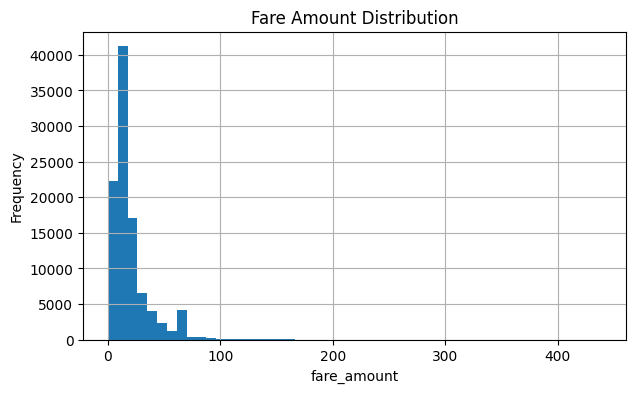

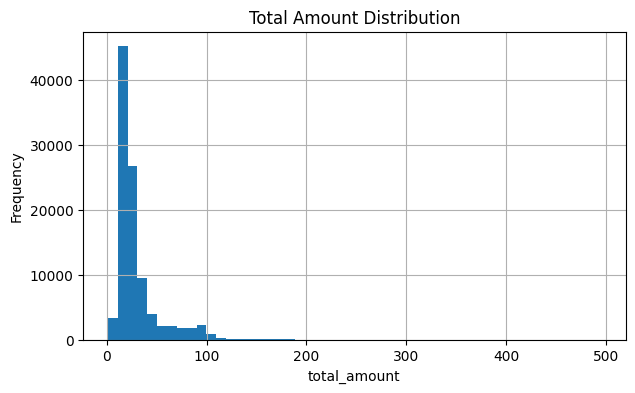

In [11]:
df_sample["fare_amount"].hist(bins=50, figsize=(7, 4))
plt.title("Fare Amount Distribution")
plt.xlabel("fare_amount")
plt.ylabel("Frequency")
plt.show()

df_sample["total_amount"].hist(bins=50, figsize=(7, 4))
plt.title("Total Amount Distribution")
plt.xlabel("total_amount")
plt.ylabel("Frequency")
plt.show()

## Create a modelling sample

This keeps runtime manageable while still using data from the full year.

In [12]:
df_model = df.sample(n=150_000, random_state=42).copy()
print(df_model.shape)

(150000, 16)


##  Time-based train/test split

Train on January-October and test on November-December. This makes sure the model actually works !!

In [13]:
train = df_model[df_model["tpep_pickup_datetime"] < "2024-11-01"].copy()
test = df_model[df_model["tpep_pickup_datetime"] >= "2024-11-01"].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (123667, 16)
Test shape: (26333, 16)


##  Building aggregated features from the training set only

This avoids leakage from the test set.

In [14]:
train_zone_stats = (
    train.groupby(["PULocationID", "pickup_hour"])
         .agg(
             avg_distance_zone=("trip_distance", "mean"),
             trip_count_zone=("trip_distance", "size")
         )
         .reset_index()
)

train_time_stats = (
    train.groupby("time_of_day")
         .agg(
             avg_fare_time_train=("fare_amount", "mean")
         )
         .reset_index()
)

train = train.merge(train_zone_stats, on=["PULocationID", "pickup_hour"], how="left")
test = test.merge(train_zone_stats, on=["PULocationID", "pickup_hour"], how="left")

train = train.merge(train_time_stats, on="time_of_day", how="left")
test = test.merge(train_time_stats, on="time_of_day", how="left")

for col in ["avg_distance_zone", "trip_count_zone", "avg_fare_time_train"]:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

train[["avg_distance_zone", "trip_count_zone", "avg_fare_time_train"]].head()

,avg_distance_zone,trip_count_zone,avg_fare_time_train
0,2.062372,215,18.954214
1,2.370286,70,19.505032
2,1.978519,27,19.505032
3,2.249573,117,20.675936
4,2.485000,2,19.505032


##  Our final feature set

These combine trip-specific and contextual features.

In [15]:
features = [
    "trip_distance",
    "trip_duration_minutes",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend",
    "passenger_count",
    "time_of_day_code",
    "avg_distance_zone",
    "trip_count_zone",
    "avg_fare_time_train",
]

features

['trip_distance',
 'trip_duration_minutes',
 'pickup_hour',
 'pickup_dayofweek',
 'pickup_month',
 'is_weekend',
 'passenger_count',
 'time_of_day_code',
 'avg_distance_zone',
 'trip_count_zone',
 'avg_fare_time_train']

##  Reusable evaluation function

In [16]:
def evaluate_models(train_df, test_df, target):
    X_train = train_df[features]
    X_test = test_df[features]
    y_train = train_df[target]
    y_test = test_df[target]

    models = {
        "Linear Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=100,
                max_depth=12,
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "Neural Network": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                max_iter=200,
                early_stopping=True,
                random_state=42
            ))
        ])
    }

    results = {}
    pred_store = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        print(f"\n{name}")
        print(f"MAE:  {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"R2:   {r2:.3f}")

        results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
        pred_store[name] = preds

    results_df = pd.DataFrame(results).T.sort_values("RMSE")
    return models, results_df, pred_store, X_test, y_test

##  Model 1: Expected fare (`fare_amount`)

In [17]:
fare_models, fare_results_df, fare_pred_store, fare_X_test, fare_y_test = evaluate_models(
    train, test, "fare_amount"
)

fare_results_df


Linear Regression
MAE:  2.67
RMSE: 6.00
R2:   0.884

Random Forest
MAE:  1.56
RMSE: 5.00
R2:   0.919

Neural Network
MAE:  1.91
RMSE: 5.16
R2:   0.914


,MAE,RMSE,R2
Random Forest,1.563257,5.000619,0.919184
Neural Network,1.906716,5.162709,0.913860
Linear Regression,2.667535,6.003039,0.883535


##  Model 2: Revenue (`total_amount`)

In [18]:
revenue_models, revenue_results_df, revenue_pred_store, revenue_X_test, revenue_y_test = evaluate_models(
    train, test, "total_amount"
)

revenue_results_df


Linear Regression
MAE:  4.30
RMSE: 8.43
R2:   0.856

Random Forest
MAE:  3.20
RMSE: 7.01
R2:   0.900

Neural Network
MAE:  3.45
RMSE: 7.23
R2:   0.894


,MAE,RMSE,R2
Random Forest,3.199345,7.009134,0.900374
Neural Network,3.450276,7.234100,0.893876
Linear Regression,4.298934,8.429338,0.855911


## 19. Choose and inspect the best revenue model

In [19]:
best_revenue_name = revenue_results_df.index[0]
best_revenue_preds = revenue_pred_store[best_revenue_name]

print("Best revenue model:", best_revenue_name)

Best revenue model: Random Forest


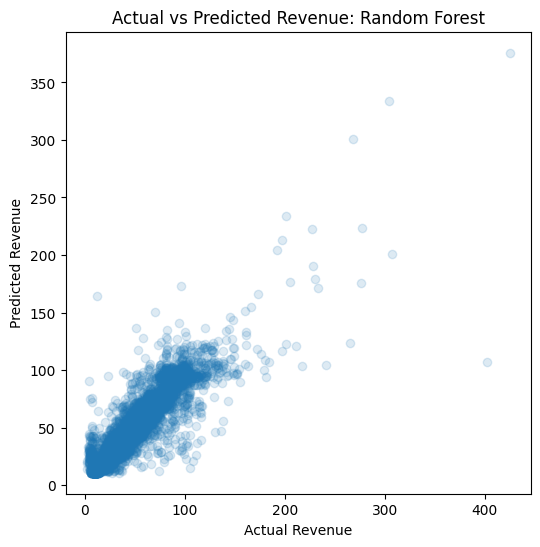

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(revenue_y_test, best_revenue_preds, alpha=0.15)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title(f"Actual vs Predicted Revenue: {best_revenue_name}")
plt.show()

##  Tune the final revenue model

We only want to tune the best model. This cell assumes Random Forest is the chosen final model.

In [21]:
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

X_train_revenue = train[features]
y_train_revenue = train["total_amount"]
X_test_revenue = test[features]
y_test_revenue = test["total_amount"]

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_revenue, y_train_revenue)
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

Best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 16}
Best CV score: -6.581562108926782


##  Evaluate the fine-tuned revenue model

In [22]:
final_revenue_model = search.best_estimator_
final_revenue_preds = final_revenue_model.predict(X_test_revenue)

final_revenue_mae = mean_absolute_error(y_test_revenue, final_revenue_preds)
final_revenue_rmse = np.sqrt(mean_squared_error(y_test_revenue, final_revenue_preds))
final_revenue_r2 = r2_score(y_test_revenue, final_revenue_preds)

print("Tuned Final Revenue Model")
print(f"MAE:  {final_revenue_mae:.2f}")
print(f"RMSE: {final_revenue_rmse:.2f}")
print(f"R2:   {final_revenue_r2:.3f}")

Tuned Final Revenue Model
MAE:  3.18
RMSE: 6.96
R2:   0.902


##  Export predictions.csv
This should be done last to avoid multi predictions.csv's

In [23]:
# predictions = test[[
#     "tpep_pickup_datetime",
#     "PULocationID",
#     "DOLocationID"
# ]].copy()

# predictions["actual_fare"] = test["fare_amount"].values
# predictions["actual_revenue"] = test["total_amount"].values

# # best untuned fare model
# best_fare_name = fare_results_df.index[0]
# predictions["predicted_fare"] = fare_pred_store[best_fare_name]

# # tuned final revenue model
# predictions["predicted_revenue"] = final_revenue_preds

# predictions.to_csv("predictions.csv", index=False)
# print("predictions.csv saved successfully.")
# predictions.head()

## The report notes for expected fare/ revenue

### Key methodological choices
- Trip-level regression was used for both expected fare and revenue.
- A time-based train/test split was used to avoid unrealistic random leakage.
- Aggregated features were built from the training set only.
- Three models were compared: Linear Regression, Random Forest, and a neural network (`MLPRegressor`).
- Only the final chosen model was tuned.(we may change this as we have meetings)

### possible disscussion points to make
- Distance and duration are the strongest predictors.
- Non-linear models outperform Linear Regression, this suggestes non-linear pricing behaviour.
- Time-of-day context improves interpretability and likely improves predictive performance.
- The model operates at the trip level but could be aggregated for higher-level revenue analysis.